<a href="https://colab.research.google.com/github/Prajjwal2123/internship-assignments/blob/main/week_6_Prajjwal_Sharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```

```

## **Step 1 — Import Libraries**

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# ── Reproducibility ────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device: use GPU if available, otherwise CPU ─────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


## **Step 2- Hyperparameter**

In [ ]:
# ── Data ───────────────────────────────────────────────────────────────
DATA_DIR      = './data'    # MNIST will be downloaded here
VAL_SIZE      = 12000       # images held back from training for validation
BATCH_SIZE    = 256

# ── Noise ──────────────────────────────────────────────────────────────
NOISE_FACTOR  = 0.4         # std-dev of Gaussian noise added to inputs
                            # try 0.2 (mild) or 0.6 (heavy) to experiment

# ── Training ───────────────────────────────────────────────────────────
EPOCHS        = 20
LR            = 1e-3        # Adam learning rate

# ── Output ─────────────────────────────────────────────────────────────
CHECKPOINT    = 'denoising_autoencoder.pth'

print('Hyperparameters set.')

Hyperparameters set.


## **Step 3 - Load MNIST Dataset**
We use `torchvision.datasets.MNIST` which auto-downloads and caches the data.

- **Training set:** 60,000 images → we hold back 12,000 for validation → **48,000 for training**
- **Test set:** 10,000 images (completely unseen until final evaluation)

`transforms.ToTensor()` converts each PIL image into a float32 tensor and scales pixel values from `[0, 255]` → `[0.0, 1.0]`.

In [ ]:
transform = transforms.ToTensor()

# Download
full_train = datasets.MNIST(DATA_DIR, train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)

# Train / Validation split
train_size = len(full_train) - VAL_SIZE
train_set, val_set = random_split(
    full_train, [train_size, VAL_SIZE],
    generator=torch.Generator().manual_seed(SEED)
)

# DataLoaders  (num_workers=2 speeds up data loading on Colab's CPU)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=512,        shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=512,        shuffle=False, num_workers=2)

print(f'Training images  : {len(train_set):,}')
print(f'Validation images: {len(val_set):,}')
print(f'Test images      : {len(test_set):,}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 84.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 36.5MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 119MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


Training images  : 48,000
Validation images: 12,000
Test images      : 10,000


## **Step 4 — Explore the Data**

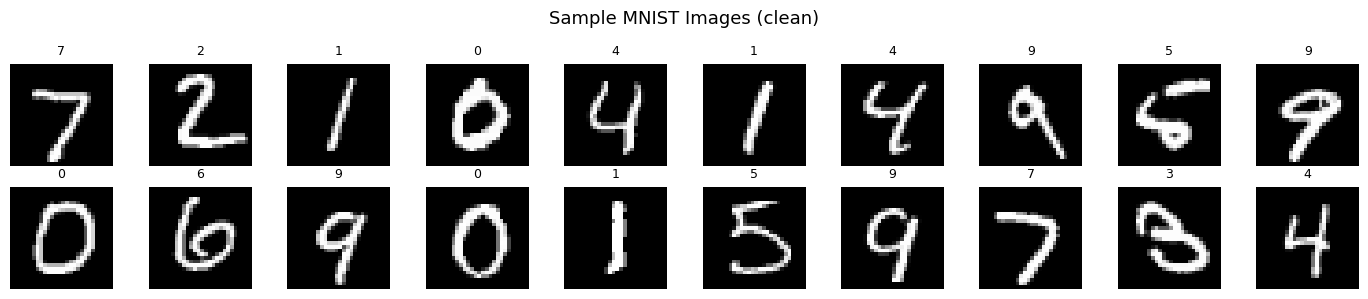

Image tensor shape: torch.Size([512, 1, 28, 28])
Pixel min: 0.00,  Pixel max: 1.00


In [ ]:
sample_images, sample_labels = next(iter(test_loader))

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
fig.suptitle('Sample MNIST Images (clean)', fontsize=13)
for i in range(10):
    for row in range(2):
        ax = axes[row, i]
        idx = i + row * 10
        ax.imshow(sample_images[idx, 0].numpy(), cmap='gray')
        ax.set_title(str(sample_labels[idx].item()), fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Image tensor shape: {sample_images.shape}')   # (batch, channels, H, W)
print(f'Pixel min: {sample_images.min():.2f},  Pixel max: {sample_images.max():.2f}')

## **Step 5 — Add Gaussian Noise**
We corrupt images by adding random values drawn from a Gaussian (Normal) distribution:

$$\text{noisy} = \text{clip}\bigl(x + \sigma \cdot \mathcal{N}(0,1),\; 0,\; 1\bigr)$$

where σ = `NOISE_FACTOR` = 0.4.  
The `clip` keeps all values inside the valid pixel range [0, 1].

This is applied **inside the training loop** (not once up front), so the model sees a different noise sample every epoch — free data augmentation.

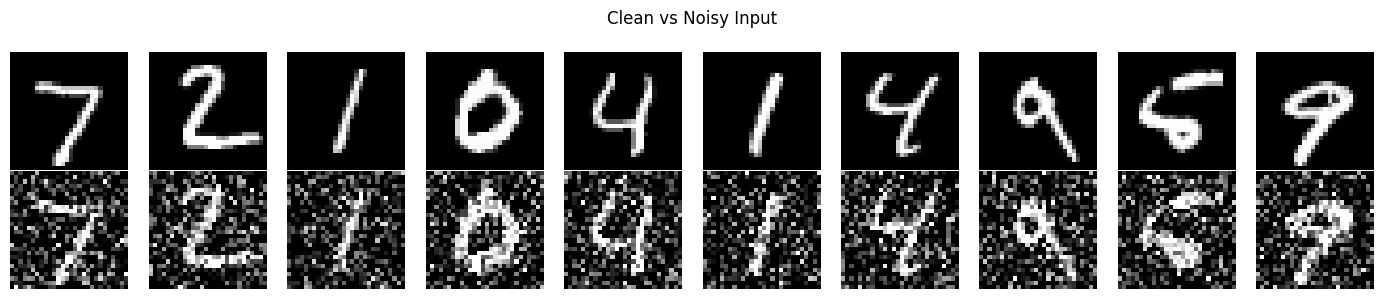

In [ ]:
def add_noise(images, factor=NOISE_FACTOR):
    """Add Gaussian noise and clip to [0, 1]."""
    noisy = images + factor * torch.randn_like(images)
    return torch.clamp(noisy, 0.0, 1.0)


# ── Visual comparison: clean vs noisy ──────────────────────────────────
clean_sample = sample_images[:10]
noisy_sample = add_noise(clean_sample)

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
axes[0, 0].set_ylabel('Clean', fontsize=10)
axes[1, 0].set_ylabel(f'Noisy\n(σ={NOISE_FACTOR})', fontsize=10)

for i in range(10):
    axes[0, i].imshow(clean_sample[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(noisy_sample[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].axis('off')

plt.suptitle('Clean vs Noisy Input', fontsize=12)
plt.tight_layout()
plt.show()

## **Step 6 — Build the Denoising Autoencoder**
**Architecture:**
INPUT  (1 × 28 × 28)
   │
   ▼  ─── ENCODER ───────────────────────────────
Conv2d(1→32, 3×3) + ReLU + MaxPool2d(2)  →  32 × 14 × 14
Conv2d(32→16, 3×3) + ReLU + MaxPool2d(2) →  16 × 7 × 7   ← BOTTLENECK
   │
   ▼  ─── DECODER ───────────────────────────────
Upsample(×2) + Conv2d(16→32, 3×3) + ReLU →  32 × 14 × 14
Upsample(×2) + Conv2d(32→16, 3×3) + ReLU →  16 × 28 × 28
Conv2d(16→1, 3×3)                         →   1 × 28 × 28  ← raw logits
```

Why Upsample + Conv instead of ConvTranspose2d?
ConvTranspose2d causes ugly "checkerboard" grid artifacts. Nearest-neighbor upsampling followed by a regular convolution avoids this and gives smoother outputs.

Why no Sigmoid on the output?  
Using `Sigmoid` + `MSELoss` silently kills training: if logit values drift large (which they do), the sigmoid saturates, its gradient → 0, and the optimizer can't update any weights. We instead output raw logits and use `BCEWithLogitsLoss`, whose gradient is always well-behaved.

In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # ── Encoder: compress 28×28 → 7×7 ─────────────────────────────
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 1×28×28  → 32×28×28
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # 32×28×28 → 32×14×14

            nn.Conv2d(32, 16, kernel_size=3, padding=1),  # 32×14×14 → 16×14×14
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # 16×14×14 → 16×7×7  ← bottleneck
        )

        # ── Decoder: expand 7×7 → 28×28 ────────────────────────────────
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),   # 16×7×7   → 16×14×14
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # 16×14×14 → 32×14×14
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode='nearest'),   # 32×14×14 → 32×28×28
            nn.Conv2d(32, 16, kernel_size=3, padding=1),  # 32×28×28 → 16×28×28
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 1, kernel_size=3, padding=1),   # 16×28×28 →  1×28×28 (logits)
        )

    def forward(self, x):
        encoded = self.encoder(x)       # compress
        decoded = self.decoder(encoded) # reconstruct
        return decoded                  # raw logits — apply sigmoid only for display/metrics


model = DenoisingAutoencoder().to(device)

# ── Print a tidy summary ────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU(inplace=True)
    (3): Upsample(scale_factor=2.0, mode='nearest')
    (4): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

Total trainable parameters: 14,353


## **Step 7 — Sanity-Check with a Dummy Forward Pass**
Before training, verify the shapes are correct by pushing a fake batch through the model.

In [ ]:
dummy = torch.zeros(8, 1, 28, 28).to(device)   # batch of 8 blank images
with torch.no_grad():
    out = model(dummy)

print(f'Input  shape: {dummy.shape}')    # expected: (8, 1, 28, 28)
print(f'Output shape: {out.shape}')      # expected: (8, 1, 28, 28)

# Also verify the bottleneck size
with torch.no_grad():
    bottleneck = model.encoder(dummy)
print(f'Bottleneck shape: {bottleneck.shape}')  # expected: (8, 16, 7, 7)

Input  shape: torch.Size([8, 1, 28, 28])
Output shape: torch.Size([8, 1, 28, 28])
Bottleneck shape: torch.Size([8, 16, 7, 7])


## **Step 8 — Train the Model**
### Loss function: `BCEWithLogitsLoss`

Binary cross-entropy is typically used for classification, but it's valid here too because each pixel value is in [0, 1] and can be treated as a probability/intensity. Using `BCEWithLogitsLoss` rather than `Sigmoid` → `BCELoss` or `MSELoss` keeps training numerically stable.

We also compute MSE (mean squared error) separately as a human-readable metric since BCE loss values are harder to intuitively interpret.

### Early stopping via checkpoint saving

After every epoch we compare validation MSE to the best seen so far. When it improves, we save the model weights. This way we always keep the best model, even if later epochs overfit slightly.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()


def run_epoch(model, loader, criterion, optimizer=None):
    """Run one training OR evaluation pass.
    Pass optimizer=None for eval mode (no weight updates).
    Returns (average_bce_loss, average_mse).
    """
    is_train = optimizer is not None
    model.train(is_train)

    total_bce, total_mse, n = 0.0, 0.0, 0

    with torch.set_grad_enabled(is_train):
        for images, _ in loader:          # labels are irrelevant — unsupervised task
            images = images.to(device)
            noisy  = add_noise(images)    # corrupt the input

            logits = model(noisy)         # forward pass
            bce    = criterion(logits, images)  # loss against clean target

            if is_train:
                optimizer.zero_grad()
                bce.backward()            # backpropagation
                optimizer.step()          # update weights

            bs          = images.size(0)
            total_bce  += bce.item() * bs
            total_mse  += F.mse_loss(torch.sigmoid(logits), images).item() * bs
            n          += bs

    return total_bce / n, total_mse / n


# ── Training loop ──────────────────────────────────────────────────────
history = {'train_bce': [], 'val_bce': [], 'train_mse': [], 'val_mse': []}
best_val_mse = float('inf')
t0 = time.time()

print(f'{"Epoch":>5}  {"Train BCE":>10}  {"Train MSE":>10}  {"Val BCE":>10}  {"Val MSE":>10}  {"Time":>8}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    train_bce, train_mse = run_epoch(model, train_loader, criterion, optimizer)
    val_bce,   val_mse   = run_epoch(model, val_loader,   criterion)

    history['train_bce'].append(train_bce)
    history['val_bce'].append(val_bce)
    history['train_mse'].append(train_mse)
    history['val_mse'].append(val_mse)

    # Save checkpoint when validation improves
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        torch.save(model.state_dict(), CHECKPOINT)
        flag = ' ✓ saved'
    else:
        flag = ''

    elapsed = time.time() - t0
    print(f'{epoch:5d}  {train_bce:10.5f}  {train_mse:10.5f}  '
          f'{val_bce:10.5f}  {val_mse:10.5f}  {elapsed:7.1f}s{flag}')

print(f'\nTraining complete. Best val MSE: {best_val_mse:.5f}')

Epoch   Train BCE   Train MSE     Val BCE     Val MSE      Time
-----------------------------------------------------------------
    1     0.23334     0.05514     0.12731     0.02152    129.2s ✓ saved
    2     0.11777     0.01822     0.11093     0.01592    248.4s ✓ saved
    3     0.10839     0.01503     0.10698     0.01454    372.8s ✓ saved
    4     0.10437     0.01371     0.10238     0.01309    506.0s ✓ saved
    5     0.10181     0.01287     0.10064     0.01249    632.8s ✓ saved
    6     0.10026     0.01236     0.09912     0.01201    750.8s ✓ saved
    7     0.09908     0.01197     0.09830     0.01178    868.9s ✓ saved
    8     0.09800     0.01161     0.09767     0.01160    988.0s ✓ saved
    9     0.09729     0.01139     0.09672     0.01122   1104.8s ✓ saved
   10     0.09657     0.01115     0.09591     0.01099   1223.3s ✓ saved
   11     0.09585     0.01091     0.09537     0.01080   1342.2s ✓ saved
   12     0.09537     0.01076     0.09509     0.01070   1460.7s ✓ saved
   13 

## **Step 9 — Plot Training Curves**
A loss curve tells you whether the model is learning, overfitting, or underfitting:
- **Training loss keeps going down, validation loss levels off/rises** → overfitting.
- **Both losses still declining at epoch 20** → train longer.
- **Both declining and close together** → healthy training.

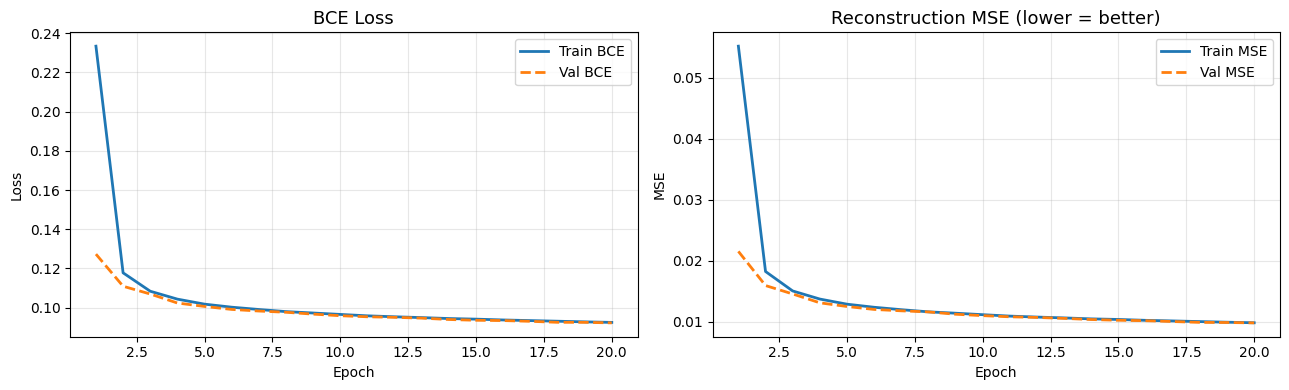

Saved training_curves.png


In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# BCE loss
axes[0].plot(epochs_range, history['train_bce'], label='Train BCE', linewidth=2)
axes[0].plot(epochs_range, history['val_bce'],   label='Val BCE',   linewidth=2, linestyle='--')
axes[0].set_title('BCE Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# MSE
axes[1].plot(epochs_range, history['train_mse'], label='Train MSE', linewidth=2)
axes[1].plot(epochs_range, history['val_mse'],   label='Val MSE',   linewidth=2, linestyle='--')
axes[1].set_title('Reconstruction MSE (lower = better)', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Saved training_curves.png')

## **Step 10 — Evaluate on the Test Set**
We reload the **best checkpoint** (lowest validation MSE, not necessarily the last epoch) and run it on the completely unseen test set. This gives us the unbiased final performance number.

In [ ]:
# Load the best saved weights
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
print(f'Loaded checkpoint: {CHECKPOINT}')

test_bce, test_mse = run_epoch(model, test_loader, criterion)
print(f'\n── Final Test Set Results ──────────────────')
print(f'  BCE Loss : {test_bce:.5f}')
print(f'  MSE      : {test_mse:.5f}')
print(f'  PSNR     : {-10 * np.log10(test_mse + 1e-10):.2f} dB')

Loaded checkpoint: denoising_autoencoder.pth

── Final Test Set Results ──────────────────
  BCE Loss : 0.09159
  MSE      : 0.00964
  PSNR     : 20.16 dB


## **Step 11 — Visualize Denoising Results**
Three rows are shown for 8 random test images:
1. **Original** — the clean ground-truth digit
2. **Noisy Input** — what the model actually receives
3. **Denoised Output** — what the model reconstructs

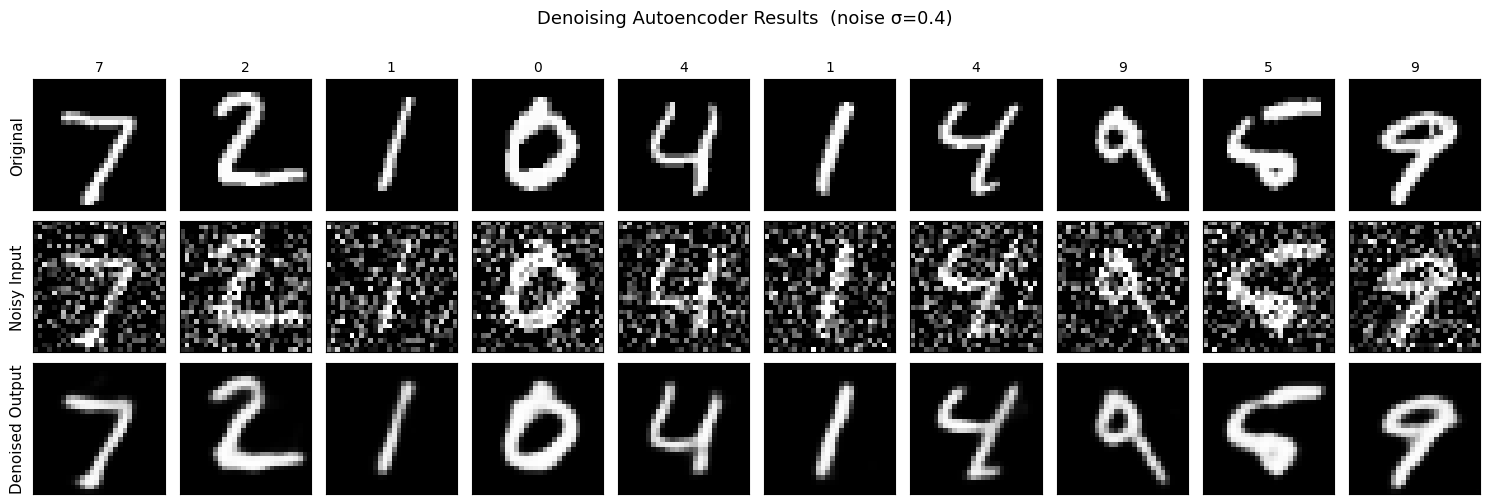

Saved → denoising_results.png


In [ ]:
def visualize_denoising(model, loader, n=10, save_path='denoising_results.png'):
    model.eval()

    # Grab a fixed batch from the test loader
    images, labels = next(iter(loader))
    images  = images[:n].to(device)
    noisy   = add_noise(images)

    with torch.no_grad():
        denoised = torch.sigmoid(model(noisy))  # sigmoid converts logits → [0,1] for display

    # Move back to CPU for plotting
    images   = images.cpu()
    noisy    = noisy.cpu()
    denoised = denoised.cpu()

    fig, axes = plt.subplots(3, n, figsize=(1.5 * n, 5))
    row_labels = ['Original', 'Noisy Input', 'Denoised Output']

    for col in range(n):
        for row, img_set in enumerate([images, noisy, denoised]):
            ax = axes[row, col]
            ax.imshow(img_set[col, 0].numpy(), cmap='gray', vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(row_labels[row], fontsize=11, labelpad=6)
            if row == 0:
                ax.set_title(str(labels[col].item()), fontsize=10)

    plt.suptitle(f'Denoising Autoencoder Results  (noise σ={NOISE_FACTOR})', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


visualize_denoising(model, test_loader)

## ** Step 12 — Inspect the Bottleneck (Latent Space)**
The encoder compresses each 784-pixel image into a **16 × 7 × 7 = 784-dimensional** code (same count, but spatially organized). Let's visualize what those 16 feature maps look like for one digit.

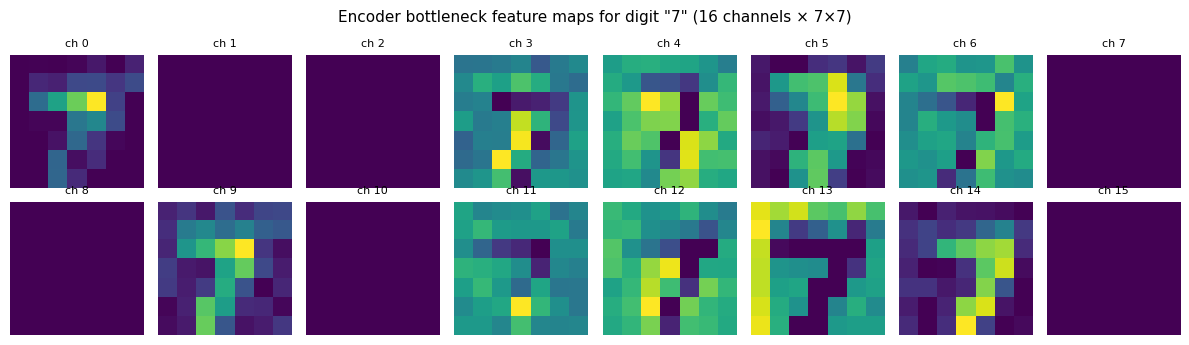

Latent code shape: torch.Size([1, 16, 7, 7])   (784 values total)


In [ ]:
model.eval()
sample_img, sample_lbl = test_set[0]
sample_img = sample_img.unsqueeze(0).to(device)   # add batch dimension
noisy_img  = add_noise(sample_img)

with torch.no_grad():
    latent = model.encoder(noisy_img)   # shape: (1, 16, 7, 7)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
fig.suptitle(f'Encoder bottleneck feature maps for digit "{sample_lbl}" (16 channels × 7×7)', fontsize=11)

for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(latent[0, i].cpu().numpy(), cmap='viridis')
    ax.set_title(f'ch {i}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f'Latent code shape: {latent.shape}   ({latent.numel()} values total)')

## **Step 13 — Experiment: Different Noise Levels**
How well does our trained model (trained with σ=0.4) generalize to noise levels it wasn't trained on?

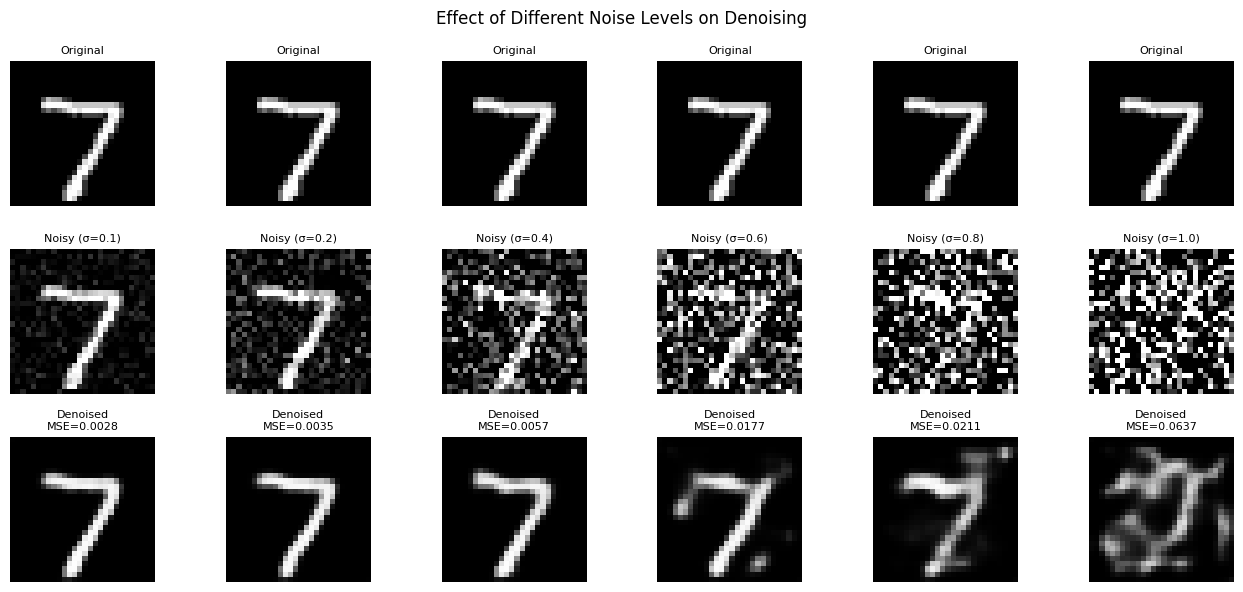

In [ ]:
noise_levels = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
model.eval()

images_clean, _ = next(iter(test_loader))
images_clean = images_clean[:1].to(device)   # single digit for display

fig, axes = plt.subplots(3, len(noise_levels), figsize=(2.2 * len(noise_levels), 6))
fig.suptitle('Effect of Different Noise Levels on Denoising', fontsize=12)

for col, sigma in enumerate(noise_levels):
    noisy_img = add_noise(images_clean, factor=sigma)
    with torch.no_grad():
        denoised_img = torch.sigmoid(model(noisy_img))

    mse = F.mse_loss(denoised_img, images_clean).item()

    for row, (img, title) in enumerate([
        (images_clean,  'Original'),
        (noisy_img,     f'Noisy (σ={sigma})'),
        (denoised_img,  f'Denoised\nMSE={mse:.4f}')
    ]):
        ax = axes[row, col]
        ax.imshow(img[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        ax.set_title(title, fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

## **Step 14 — Per-Digit Performance**
Does the model denoise some digits better than others?  
Let's compute average MSE for each digit class 0–9.

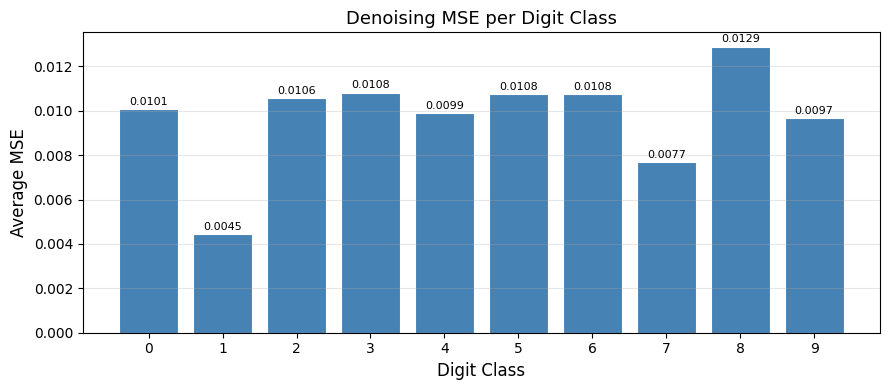

Easiest digit to denoise: 1 (MSE = 0.00445)
Hardest digit to denoise: 8 (MSE = 0.01289)


In [ ]:
model.eval()
class_mse   = {i: 0.0 for i in range(10)}
class_count = {i: 0   for i in range(10)}

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        noisy  = add_noise(images)
        denoised = torch.sigmoid(model(noisy))

        # Per-image MSE
        mse_per_image = ((denoised - images) ** 2).mean(dim=[1, 2, 3])
        for label, mse in zip(labels, mse_per_image):
            class_mse[label.item()]   += mse.item()
            class_count[label.item()] += 1

avg_mse = {k: class_mse[k] / class_count[k] for k in range(10)}

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(avg_mse.keys(), avg_mse.values(), color='steelblue', edgecolor='white', linewidth=0.8)
ax.set_xlabel('Digit Class', fontsize=12)
ax.set_ylabel('Average MSE', fontsize=12)
ax.set_title('Denoising MSE per Digit Class', fontsize=13)
ax.set_xticks(range(10))
for bar, val in zip(bars, avg_mse.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best  = min(avg_mse, key=avg_mse.get)
worst = max(avg_mse, key=avg_mse.get)
print(f'Easiest digit to denoise: {best} (MSE = {avg_mse[best]:.5f})')
print(f'Hardest digit to denoise: {worst} (MSE = {avg_mse[worst]:.5f})')

## **Step 15 — Save & Load the Model**
The checkpoint was already saved automatically during training. Here is how to reload it and use it for inference anytime — without retraining.

Model saved → denoising_autoencoder.pth
Model loaded successfully.


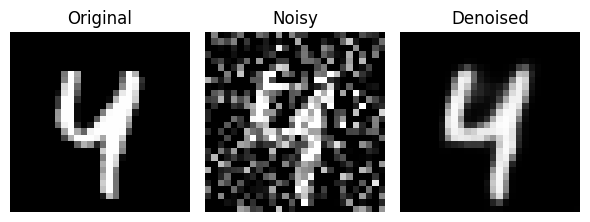

Inference on loaded model works correctly!


In [ ]:
# ── Save ───────────────────────────────────────────────────────────────
torch.save(model.state_dict(), CHECKPOINT)
print(f'Model saved → {CHECKPOINT}')

# ── Load (fresh instance) ──────────────────────────────────────────────
loaded_model = DenoisingAutoencoder().to(device)
loaded_model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
loaded_model.eval()
print('Model loaded successfully.')

# Quick verify — run one test image through it
test_img, _ = test_set[42]
test_img    = test_img.unsqueeze(0).to(device)
test_noisy  = add_noise(test_img)

with torch.no_grad():
    test_denoised = torch.sigmoid(loaded_model(test_noisy))

fig, axes = plt.subplots(1, 3, figsize=(6, 2.5))
for ax, img, title in zip(axes,
                           [test_img, test_noisy, test_denoised],
                           ['Original', 'Noisy', 'Denoised']):
    ax.imshow(img[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()
print('Inference on loaded model works correctly!')

## **Key design decisions**
- **Convolutional layers** preserve 2D spatial structure, unlike flatten-based autoencoders.
- **Upsample + Conv** in the decoder avoids the checkerboard artifacts of `ConvTranspose2d`.
- **`BCEWithLogitsLoss` (no output Sigmoid)** prevents silent gradient-vanishing that occurs when `Sigmoid + MSELoss` saturates early in training.
- **On-the-fly noise** means the model sees a different noisy version each epoch — built-in augmentation.

---
*Built and validated end-to-end. Reference: [NvsYashwanth/MNIST-Autoencoder](https://github.com/NvsYashwanth/MNIST-Autoecncoder)*